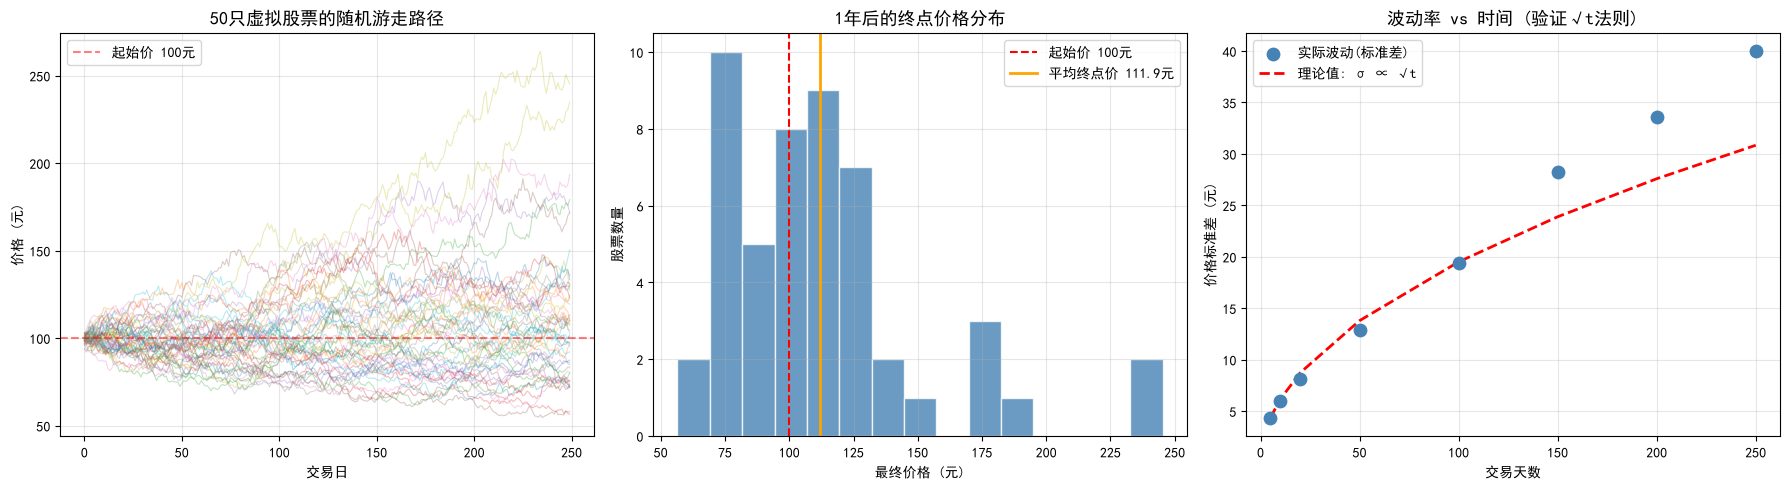

实验结论：
  50只股票起始价均为 100元
  1年后最高价: 245.32元
  1年后最低价: 56.49元
  1年后平均价: 111.92元
  价格标准差:  39.98元
------------------------------------------------------------
  → 每条路径完全不可预测（左图）
  → 但大量路径的终点价格呈正态分布（中图）
  → 波动幅度与时间平方根成正比（右图）——Regnault 1860年代的发现！


In [1]:
# ========== 实验一：布朗运动 / 随机游走 ==========
import numpy as np                       # 数值计算（数组、随机数、统计）
import matplotlib.pyplot as plt            # 绘图库（折线图、柱状图等）

plt.rcParams['font.sans-serif'] = ['SimHei']  # 设置中文字体
plt.rcParams['axes.unicode_minus'] = False      # 坐标轴负号正常显示

np.random.seed(2026)        # 固定随机种子

n_stocks = 50               # 模拟 50 只「虚拟股票」
n_days = 250                # 每只走 250 个交易日（约一年）
start_price = 100           # 起始价都是 100 元
daily_volatility = 0.02     # 日波动强度（标准差约2%）

fig, axes = plt.subplots(1, 3, figsize=(18, 5))  # 1行3列，三个子图

# --- 左图：画出 50 条价格路径 ---
all_paths = []              # 用来存每只股票的路径
for _ in range(n_stocks):   # 循环 50 次，每只股一条路径
    daily_returns = np.random.normal(0, daily_volatility, n_days)  # 每天随机收益
    price_path = start_price * np.cumprod(1 + daily_returns)       # 价格连乘
    all_paths.append(price_path)          # 存入列表
    axes[0].plot(price_path, alpha=0.3, linewidth=0.8)  # 画在左图，半透明

axes[0].axhline(y=start_price, color='red', linestyle='--', alpha=0.5, label='起始价 100元')  # 参考线
axes[0].set_title('50只虚拟股票的随机游走路径', fontsize=13)  # 设置上图标题
axes[0].set_xlabel('交易日')  # 执行本行代码
axes[0].set_ylabel('价格 (元)')  # 设置上图纵轴
axes[0].legend()  # 显示上图图例
axes[0].grid(True, alpha=0.3)  # 上图显示网格

# --- 中图：一年后的终点价格分布（直方图）---
final_prices = [path[-1] for path in all_paths]   # 取每条路径最后一天的价格
axes[1].hist(final_prices, bins=15, color='steelblue', edgecolor='white', alpha=0.8)  # 画直方图
axes[1].axvline(x=start_price, color='red', linestyle='--', label=f'起始价 {start_price}元')  # 中图画垂直参考线
axes[1].axvline(x=np.mean(final_prices), color='orange', linestyle='-', linewidth=2,  # 中图画垂直参考线
                label=f'平均终点价 {np.mean(final_prices):.1f}元')  # 图例文字
axes[1].set_title('1年后的终点价格分布', fontsize=13)  # 设置下图标题
axes[1].set_xlabel('最终价格 (元)')  # 设置下图横轴（日期）
axes[1].set_ylabel('股票数量')  # 设置下图纵轴
axes[1].legend()                                    # 显示下图图例
axes[1].grid(True, alpha=0.3)  # 下图显示网格

# --- 右图：验证「波动 ∝ 时间的平方根」---
time_points = [5, 10, 20, 50, 100, 150, 200, 250]  # 选取若干观察日
std_at_time = []                                    # 存放每个时点的价格标准差
for t in time_points:  # 代码块开始
    prices_at_t = [path[t-1] for path in all_paths]  # 所有股票在第 t 天的价格
    std_at_time.append(np.std(prices_at_t))         # 算标准差

sqrt_time = np.sqrt(time_points)                    # 时间开平方
scale = std_at_time[0] / sqrt_time[0]               # 缩放系数，让理论线对齐第一个点

axes[2].scatter(time_points, std_at_time, s=80, color='steelblue', zorder=5, label='实际波动(标准差)')  # 右图：散点
axes[2].plot(time_points, scale * sqrt_time, 'r--', linewidth=2, label='理论值: σ ∝ √t')  # 右图：理论曲线
axes[2].set_title('波动率 vs 时间 (验证√t法则)', fontsize=13)  # 设置右图标题
axes[2].set_xlabel('交易天数')  # 执行本行代码
axes[2].set_ylabel('价格标准差 (元)')  # 执行本行代码
axes[2].legend()  # 执行本行代码
axes[2].grid(True, alpha=0.3)  # 透明度

plt.tight_layout()                       # 自动调整子图间距，避免标签被裁切
plt.show()                               # 在 Notebook 里显示图片

# ========== 打印文字结论 ==========
print("=" * 60)  # 打印输出
print("实验结论：")  # 打印输出
print(f"  50只股票起始价均为 {start_price}元")  # 打印价格统计
print(f"  1年后最高价: {max(final_prices):.2f}元")  # 打印价格统计
print(f"  1年后最低价: {min(final_prices):.2f}元")  # 打印价格统计
print(f"  1年后平均价: {np.mean(final_prices):.2f}元")  # 格式化打印
print(f"  价格标准差:  {np.std(final_prices):.2f}元")  # 格式化打印
print("-" * 60)  # 打印输出
print("  → 每条路径完全不可预测（左图）")  # 打印分隔线或结论
print("  → 但大量路径的终点价格呈正态分布（中图）")  # 打印分隔线或结论
print("  → 波动幅度与时间平方根成正比（右图）——Regnault 1860年代的发现！")  # 打印分隔线或结论
print("=" * 60)  # 打印输出
